In [ ]:
import pandas as pd

In [ ]:
# The `FileNotFoundError` indicates that the file '/content/Employee_Performance_dataset.csv'
# could not be found at the specified location.
# Please upload the 'Employee_Performance_dataset.csv' file to your Colab environment
# (e.g., by dragging and dropping it into the file browser on the left sidebar)
# or update the path if the file is located elsewhere.

# Once the file is available, uncomment the line below to load the DataFrame:
df = pd.read_csv("/content/Employee_Performance_dataset.csv")

In [ ]:
df.shape

(1000, 12)

In [ ]:
df.columns

Index(['ID', 'Name', 'Age', 'Gender', 'Department', 'Salary', 'Joining Date',
       'Performance Score', 'Experience', 'Status', 'Location', 'Session'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 1000 non-null   int64  
 1   Name               1000 non-null   object 
 2   Age                1000 non-null   int64  
 3   Gender             1000 non-null   object 
 4   Department         1000 non-null   object 
 5   Salary             1000 non-null   int64  
 6   Joining Date       1000 non-null   object 
 7   Performance Score  502 non-null    float64
 8   Experience         1000 non-null   int64  
 9   Status             1000 non-null   object 
 10  Location           1000 non-null   object 
 11  Session            1000 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 93.9+ KB


In [ ]:
df.isnull().sum()

,0
ID,0
Name,0
Age,0
Gender,0
Department,0
Salary,0
Joining Date,0
Performance Score,498
Experience,0
Status,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,ID,Age,Salary,Performance Score,Experience
count,1000.000000,1000.000000,1000.000000,502.000000,1000.000000
mean,500.500000,40.782000,5917.374000,2.910359,10.120000
std,288.819436,14.124871,2299.418003,1.424736,5.713689
min,1.000000,18.000000,2015.000000,1.000000,1.000000
25%,250.750000,28.000000,3829.750000,2.000000,5.000000
50%,500.500000,40.000000,5889.000000,3.000000,10.000000
75%,750.250000,52.000000,7903.250000,4.000000,15.000000
max,1000.000000,65.000000,9993.000000,5.000000,20.000000


In [ ]:
df["Salary"].mean()

np.float64(5917.374)

In [ ]:
df.groupby("Department")["Salary"].mean()

,Salary
Department,
HR,5982.396285
IT,5968.371681
Sales,5804.088757


In [ ]:
df.groupby("Department")["Salary"].mean().round(2)

,Salary
Department,
HR,5982.40
IT,5968.37
Sales,5804.09


In [ ]:
df["Department"].value_counts()

,count
Department,
IT,339
Sales,338
HR,323


In [ ]:
df.columns.tolist()

['ID',
 'Name',
 'Age',
 'Gender',
 'Department',
 'Salary',
 'Joining Date',
 'Performance Score',
 'Experience',
 'Status',
 'Location',
 'Session']

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.columns.tolist()

['ID',
 'Name',
 'Age',
 'Gender',
 'Department',
 'Salary',
 'Joining Date',
 'Performance Score',
 'Experience',
 'Status',
 'Location',
 'Session']

In [ ]:
df["Joining Date"] = pd.to_datetime(df["Joining Date"], errors="coerce")

In [ ]:
df["Performance Score"].dtype

dtype('float64')

In [ ]:
df["Performance Score"] =pd.to_numeric(
    df["Performance Score"],
    errors="coerce"
)

In [ ]:
df["Performance Score"].dtype

dtype('float64')

In [ ]:
df.isnull().sum()

,0
ID,0
Name,0
Age,0
Gender,0
Department,0
Salary,0
Joining Date,0
Performance Score,498
Experience,0
Status,0


In [ ]:
df.to_csv("Employee_Performance_Cleaned.csv", index=False)

In [ ]:
df["Joining Date"] = pd.to_datetime(df["Joining Date"], errors="coerce")

df["Performance Score"] = pd.to_numeric(
    df["Performance Score"],
    errors="coerce"
)

df.isnull().sum()

,0
ID,0
Name,0
Age,0
Gender,0
Department,0
Salary,0
Joining Date,0
Performance Score,498
Experience,0
Status,0


In [ ]:
df["Performance Score"].describe()

,Performance Score
count,502.000000
mean,2.910359
std,1.424736
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [ ]:
df["Performance Score"].value_counts().sort_index()

,count
Performance Score,
1.0,103
2.0,125
3.0,87
4.0,88
5.0,99


In [ ]:
df["Performance Score"].mean()

np.float64(2.910358565737052)

In [ ]:
round(df["Performance Score"].mean(), 2)

np.float64(2.91)

In [ ]:
df.groupby("Department")["Performance Score"].mean().round(2)

,Performance Score
Department,
HR,2.86
IT,2.98
Sales,2.90


In [ ]:
df.groupby("Location")["Performance Score"].mean().round(2)

,Performance Score
Location,
Chicago,2.94
Los Angeles,2.92
New York,2.86


In [ ]:
df.groupby("Gender")["Performance Score"].mean().round(2)

,Performance Score
Gender,
Female,3.11
Male,2.77
Other,2.85


In [ ]:
df.groupby("Performance Score")["Salary"].mean().round(2)

,Salary
Performance Score,
1.0,6121.54
2.0,5613.04
3.0,5771.17
4.0,5859.67
5.0,5983.26


In [ ]:
df.groupby("Experience")["Salary"].mean().round(2)

,Salary
Experience,
1,5958.55
2,6523.47
3,6159.65
4,5632.67
5,5766.34
6,5507.65
7,5960.78
8,5615.98
9,5888.86


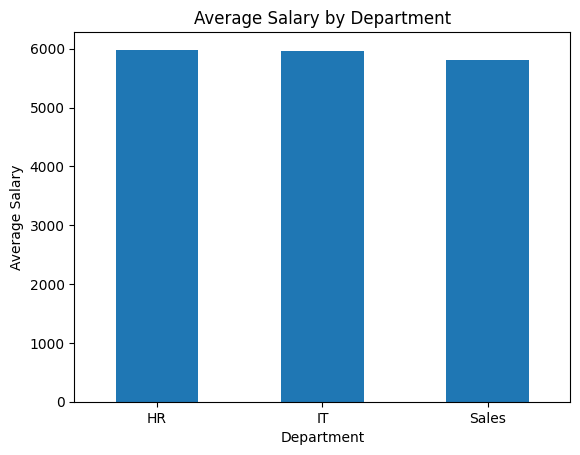

In [ ]:
import matplotlib.pyplot as plt

salary_dept = df.groupby("Department")["Salary"].mean()

salary_dept.plot(kind="bar")

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=0)
plt.show()

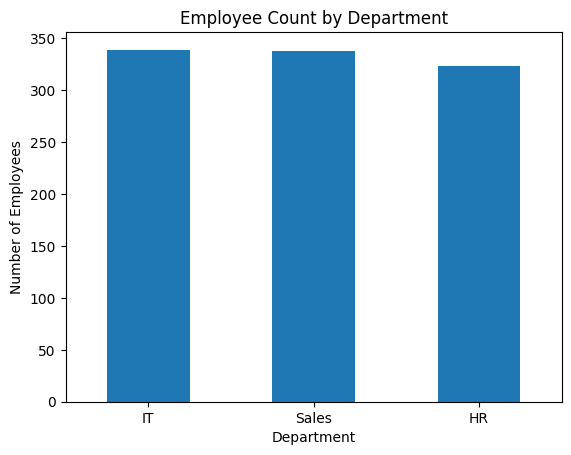

In [ ]:
employee_dept = df["Department"].value_counts()

employee_dept.plot(kind="bar")

plt.title("Employee Count by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

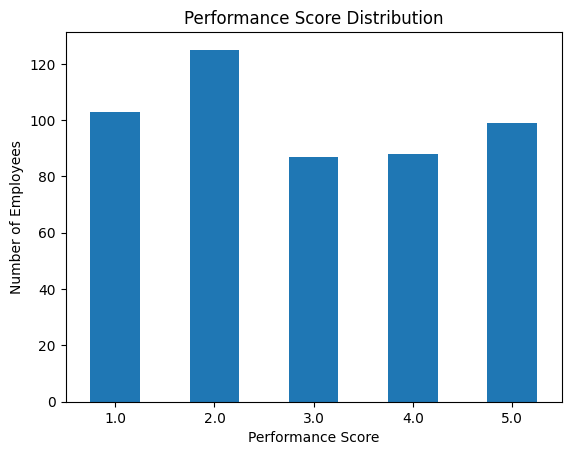

In [ ]:
performance_count = df["Performance Score"].value_counts().sort_index()

performance_count.plot(kind="bar")

plt.title("Performance Score Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

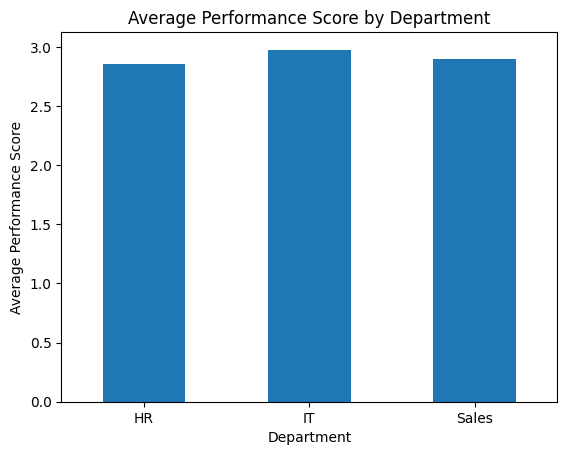

In [ ]:
performance_dept = df.groupby("Department")["Performance Score"].mean()

performance_dept.plot(kind="bar")

plt.title("Average Performance Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=0)
plt.show()

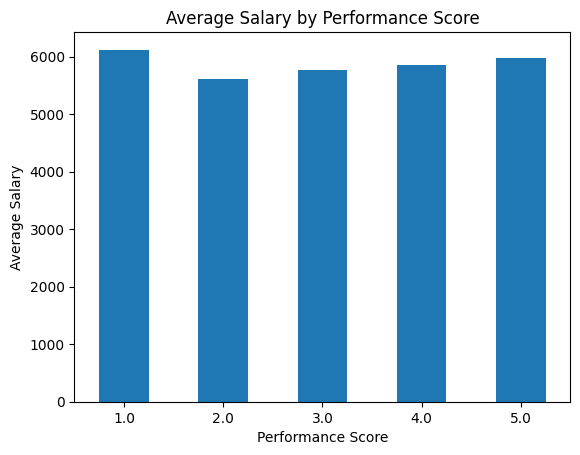

In [ ]:
salary_performance = df.groupby("Performance Score")["Salary"].mean()

salary_performance.plot(kind="bar")

plt.title("Average Salary by Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Average Salary")
plt.xticks(rotation=0)
plt.show()

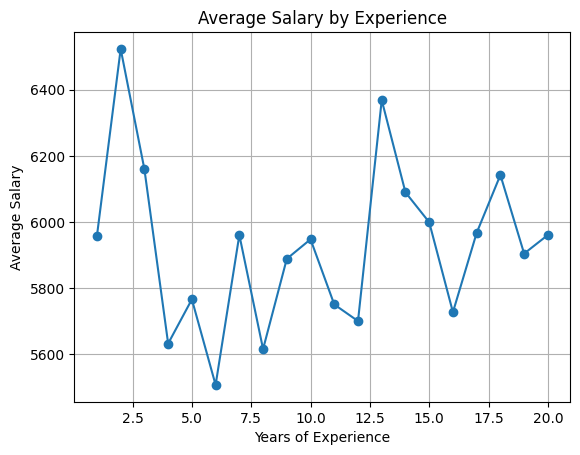

In [ ]:
experience_salary = df.groupby("Experience")["Salary"].mean()

experience_salary.plot(kind="line", marker="o")

plt.title("Average Salary by Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Average Salary")
plt.grid(True)
plt.show()

In [ ]:
from google.colab import files

files.download("Employee_Performance_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>